# Lecture 04 - Exercise: Upsampling

In [213]:
#######################
### L04 - Exercises ###
#######################

# importing libraries and setting up nice plots

import os
import random
import numpy                    as     np
import matplotlib.pyplot        as     plt
import matplotlib.patches       as     patches
import matplotlib.ticker		as     tck
import matplotlib.colors		as     colors
from   matplotlib				import rc
from   matplotlib.gridspec		import GridSpec
from   scipy                    import stats, interpolate
from   astroML.datasets         import fetch_dr7_quasar
from   astropy.cosmology        import Planck15
from   astropy.visualization    import hist
from   astroML.density_estimation import EmpiricalDistribution


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

# did we start this notebook from ".../GitHub/working" directory or from ".../GitHub" (by accident)?
current_pwd = os.getcwd()



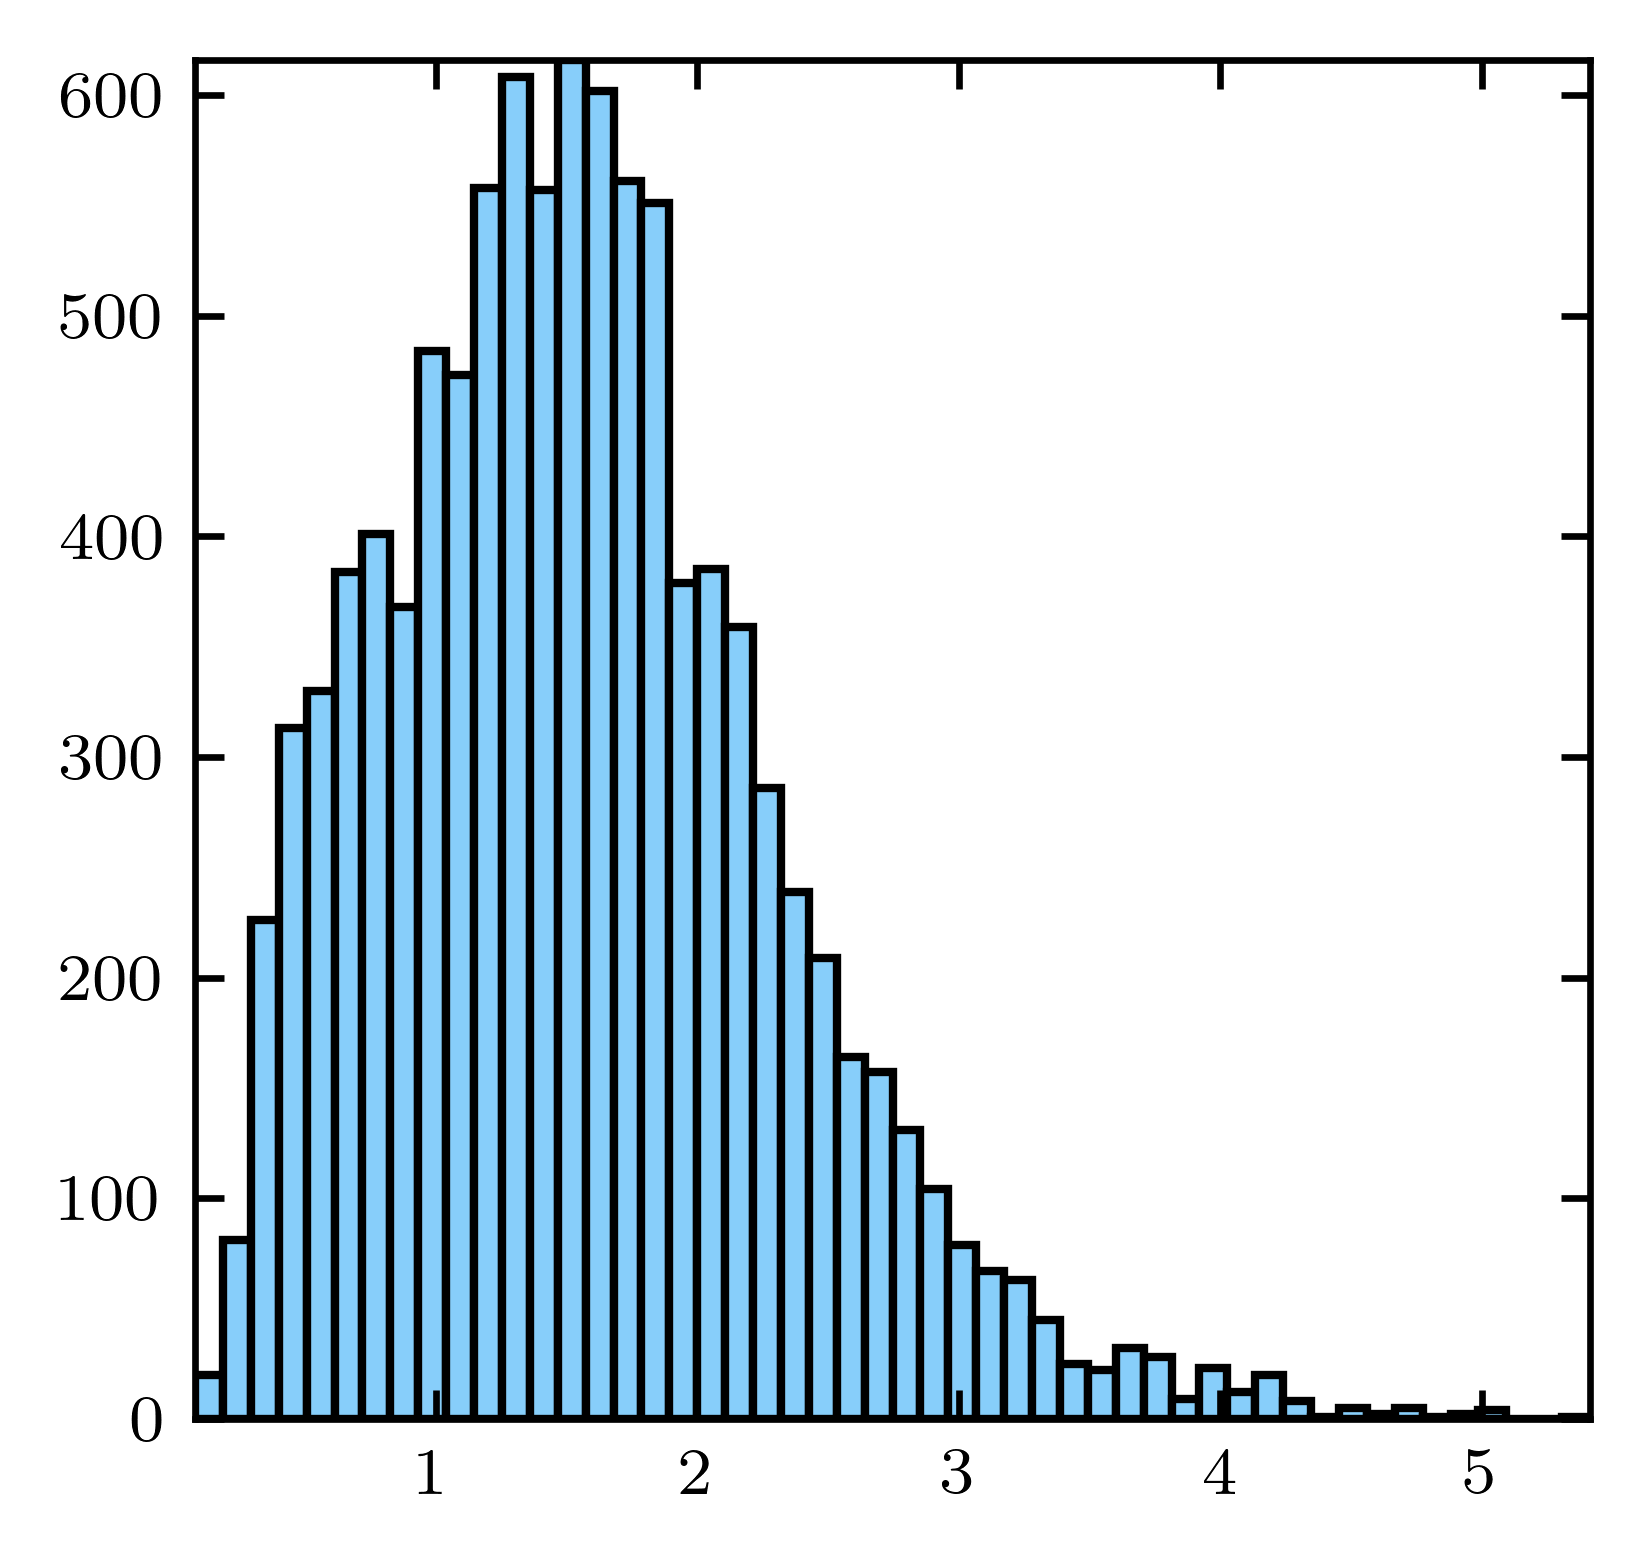

In [214]:
# Fetch quasar data
data = fetch_dr7_quasar()

# Select only the data we wish to use:
data_copy = np.copy(data)
data_copy = data_copy[:10000]
z = data_copy['redshift']

# Extremely quick plot to visualize the dataset we wish to clone
fig , ax = plt.subplots(1,1,figsize=(3,3))
z_histo = ax.hist( z, bins=50, density=False, color='lightskyblue', edgecolor='black')
plt.show()


In [215]:
# Quick investigation for some boundaries and basic stat. properties
z_mean = np.mean(z)
z_max  = np.max(z)
z_min  = np.min(z)
y_max = z_histo[0].max()

print('z mean = {:.2f}'.format(z_mean))
print('z max  = {:.2f}'.format(z_max))
print('z min  = {:.2f}'.format(z_min))
print('max z count = {:.0f}'.format(y_max))

# Show data size and set resampling size 
N_data  = len(z)
N_clone = 100000
print('N_data  = {:d}'.format(N_data))
print('N_clone = {:d} = {:.0f} x N_data'.format(N_clone, N_clone/N_data))



z mean = 1.56
z max  = 5.41
z min  = 0.08
max z count = 616
N_data  = 10000
N_clone = 100000 = 10 x N_data


# Resampling method 1 - Inverse Transform Sampling

In [216]:
#########################################################################
### L04 - Exercise 1: Cloning dataset with Inverse Transform Sampling ###
#########################################################################

### NOTE: we are just showing our understending of the theoretical steps
###       we will then use a built-in function in astropy to clone the data

# create a cumulative distribution from the measured data
z.sort()
cdf_z = np.linspace(0, 1, N_data) 

# set up an interpolation of the inverse cumulative distribution
# note the usage of splrep (spline representation):
# function(var_x) = interpolate.splrep( var_y = cdf(x), var_x = x )
cdf_interpol = interpolate.splrep(cdf_z, z)

# sample evenly (and densely) along the cumulative distribution, and interpolate
# note the usage of splev (spline evaluation):
# var_x' = interpolate.splev( var_y' , func = interpolate.splrep( var_y, var_x ) )
cdf_z_sample = np.linspace(0, 1, 10 * N_data)
z_sample = interpolate.splev(cdf_z_sample, cdf_interpol)

    
#------------------------------------------------------------
# Clone the measured distribution with astroML.density_estimation.EmpiricalDistribution
z_cloned = EmpiricalDistribution(z).rvs(N_clone)

# compute the KS test to check whether the clone data comes from the distribution
D, p = stats.ks_2samp(z, z_cloned)
print("KS test: D = %.10g; p = %.10g" % (D, p))


KS test: D = 0.00423; p = 0.9966439869


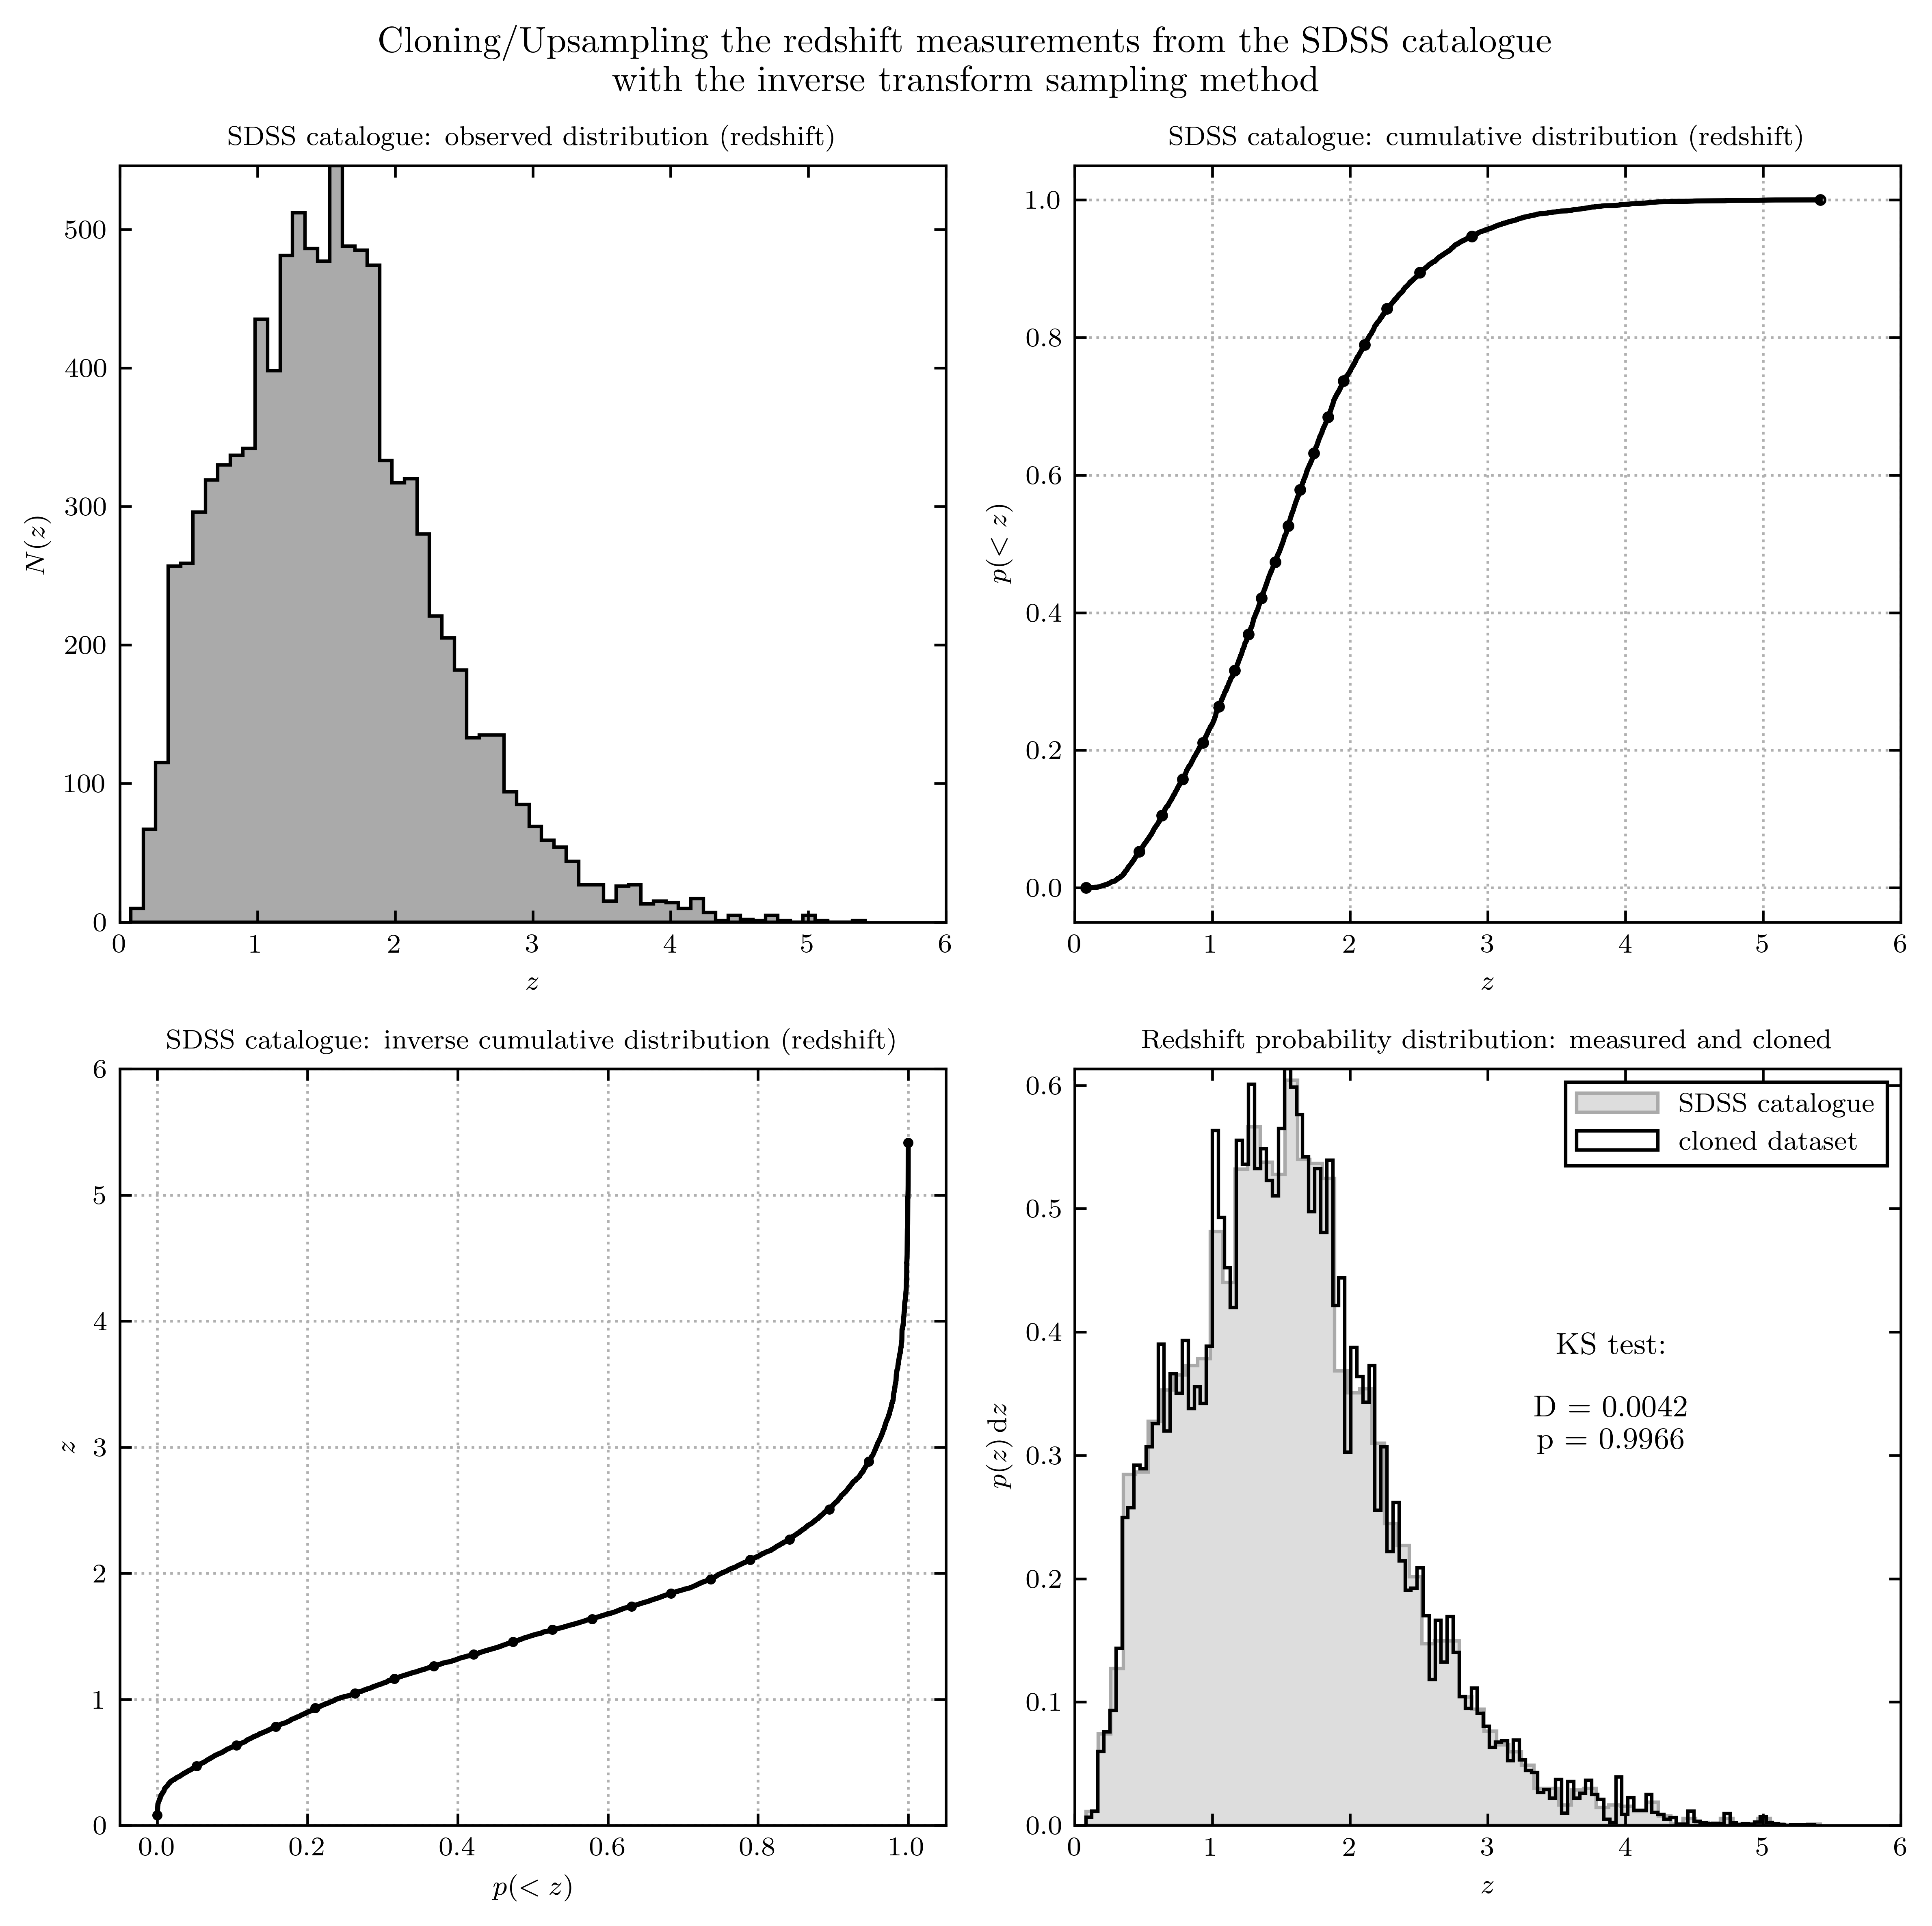

In [223]:
#------------------------------------------------------------
# Plot the cloned distribution and the procedure for obtaining it
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(
    hspace = 0.2, # 0.30, 
    left   = 0.0, # 0.10, 
    right  = 0.9, # 0.95, 
    bottom = 0.0, # 0.08, 
    top    = 0.9, # 0.92, 
    wspace = 0.2, # 0.30
)

indices = np.linspace(0, len(z) - 1, 20).astype(int)

# plot a histogram of the input
ax = fig.add_subplot(221)
hist(z, bins='knuth', ax=ax, histtype='stepfilled', ec='k', fc='#AAAAAA')
ax.set_xlim(0,6)
ax.set_title('SDSS catalogue: observed distribution (redshift)')
ax.set_xlabel('$z$')
ax.set_ylabel('$N(z)$')

# plot the cumulative distribution
ax = fig.add_subplot(222)
ax.scatter(z[indices], cdf_z[indices], lw=0, c='k', s=12)   # just the "dots"
ax.plot(z, cdf_z, '-k')
ax.set_xlim(0,6)
ax.set_ylim(-0.05, 1.05)
ax.grid(ls=':')
ax.set_title('SDSS catalogue: cumulative distribution (redshift)')
ax.set_xlabel('$z$')
ax.set_ylabel('$p(<z)$')

# plot the inverse cumulative distribution and spline fit
ax = fig.add_subplot(223)
ax.scatter(cdf_z[indices], z[indices], lw=0, c='k', s=9)
ax.plot(cdf_z_sample, z_sample, '-k')
# ax.arrow(0.7, -3.0,  0.00, 3.5, width=0.015, fc='gray', ec='gray', head_width=0.05, head_length=0.40)
# ax.arrow(0.7,  0.9, -0.69, 0.0, width=0.100, fc='gray', ec='gray', head_width=0.30, head_length=0.06)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0,6)
ax.grid(ls=':')
ax.set_title('SDSS catalogue: inverse cumulative distribution (redshift)')
ax.set_xlabel('$p(<z)$')
ax.set_ylabel('$z$')

# plot the resulting cloned distribution
ax = fig.add_subplot(224)
hist(z, bins='knuth', ax=ax, histtype='stepfilled', density=True, ec='#AAAAAA', fc='#DDDDDD', label='SDSS catalogue')
hist(z_cloned, bins='knuth', ax=ax, histtype='step', density=True, color='k', label='cloned dataset')
ax.set_xlim(0,6)
ax.set_title('Redshift probability distribution: measured and cloned')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$p(z) \, \textup{d}z$')
ax.text(0.65, 0.65, "KS test:\n\nD = %.4f\np = %.4f" % (D, p), ha='center', va='top', transform=ax.transAxes)

ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=1)

fig.suptitle(
    "Cloning/Upsampling the redshift measurements from the SDSS catalogue" 
    + "\n"
    + "with the inverse transform sampling method"
)

# do we want to save the figure?
fig.tight_layout()
if True:
    if current_pwd[-6:] == 'GitHub':
        fig.savefig('./working/L04_images/L04_Cloning_Upsampling_SDSS__Inverse_Transform_Sampling_Method.pdf', bbox_inches='tight')
    elif current_pwd[-14:] == 'GitHub\working':
        fig.savefig('./L04_images/L04_Cloning_Upsampling_SDSS__Inverse_Transform_Sampling_Method.pdf', bbox_inches='tight')

In [218]:

Z = np.random.uniform(0,2*z_max,N)
for x in Z:
    u = np.random.uniform(0,y_max,1)